# Dexed × adtool : comprendre l'intégration IMGEP

Ce notebook explique comment le système Dexed a été branché dans **adtool** (framework de
curiosité artificielle d'Inria Flowers), et permet d'explorer/visualiser les découvertes d'une
expérience IMGEP.

## Le formalisme adtool : Θ → O → Z

- **Θ (paramètres)** : les 155 paramètres bruts d'un preset Dexed (144 "apprenables", 11 fixés
  à des valeurs par défaut comme dans le dataset spinvae2).
- **O (sortie/simulation)** : le rendu audio du preset via DawDreamer, sur une note MIDI de
  référence fixe (pitch=56, velocity=75 -- la même que tout le dataset spinvae2).
- **Z (comportement)** : l'espace canonique complet à **38 dimensions** du papier SpinVAE2
  (6 ACTM + 32 TT), calculé **sans MATLAB** -- ACTM directement en Python, et TT via `ttb`
  (le port Python de TimbreToolbox, validé/débogué durant ce stage, voir
  `spinvae2/notebooks/dexed_audit_TT_ACTM.ipynb`). Ça rend Z directement comparable à la
  couverture du dataset humain (30 145 presets).

## Les briques (dans `spinvae2/adtool/dexed/`)

Le dossier a été déplacé depuis `adtool/examples/dexed/` (dépôt adtool) vers
`spinvae2/adtool/dexed/`, et refactoré pour suivre les conventions du
[TUTORIAL adtool](../../docs/TUTORIAL.md) (mêmes conventions que les exemples officiels du
dépôt, ex. `examples/lenia/`) :

| Fichier / config | Rôle | Concept adtool |
|---|---|---|
| `maps/DexedParameterMap.py` | `sample()` (preset aléatoire) et `mutate()` (perturbation) | Paramètres (Θ) |
| `systems/Dexed.py` | Rendu audio via DawDreamer, hérite de `adtool.systems.System.System` | Système (Θ→O) |
| `maps/DexedStatistics.py` | Calcul de l'embedding 38D (6 ACTM + 32 TT) | Comportement (O→Z) |
| `dexed.json` -> `explorer.config.mutator` | `SpecificMutator` : délègue à `DexedParameterMap.mutate()` | Mutateur |

L'explorateur IMGEP (`adtool.explorers.IMGEPExplorer`) orchestre la boucle : il choisit un
"but" dans l'espace Z déjà découvert, mute un preset proche de ce but (via le mutateur, voir
section 2.4 plus bas), l'évalue, et sauvegarde la découverte si elle est jugée suffisamment
nouvelle.

**Détail d'implémentation important -- checkpointing** : `DexedSimulation` et
`DexedParameterMap` détiennent chacun un moteur DawDreamer natif (`dexed_engine`,
`_dexed_helper`) qui ne peut pas être picklé. adtool sauvegarde un checkpoint après chaque
découverte (`pickle.dump` de l'état de chaque `Leaf`), donc ces moteurs sont chargés en lazy
(property, construits au premier accès) et exclus de l'état sauvegardé via la méthode
`checkpoint_state()` (le hook que `adtool.utils.persistence.checkpoint` utilise à la place de
`__getstate__`/`__setstate__` -- le rechargement d'un checkpoint fait `cls.__new__(cls)` puis
`__dict__.update(state)`, sans repasser par `__init__`, donc `__setstate__` ne suffit pas ici).

**Coût de calcul, mesuré (pas estimé)** : le passage à Z=38D (au lieu d'ACTM seul, 7D) a un vrai
coût -- `ttb` domine le temps d'évaluation (voir section 8 pour le detail du profiling). Le
Readme annonçait initialement ~10-12s/évaluation sur des presets aléatoires ; le coût réel
mesuré sur le random baseline (2000 évaluations chronométrées) est **~5.8s/évaluation** --
l'ancienne estimation datait probablement d'avant les correctifs NumPy2/librosa de ce stage, ou
d'une machine plus chargée à l'époque. À ce rythme, un run continu de 2000 (`run_2000_v2`) a
pris **1h20 en pratique** (15:57 -> 17:18), contre les 6-7h originellement crainte pour
`run_2000_38D` (ancienne stack, ~7h reelles). Voir section 8 pour l'investigation complète
(pourquoi on n'a pas eu besoin de dégrader la précision de `ttb` pour l'accélérer).

## 1. Setup

In [1]:
import sys, os, pathlib
sys.path.insert(0, str(pathlib.Path.home() / 'projects' / 'spinvae2'))
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH', '')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

# dexed.json's "path" entries (systems.Dexed..., maps.DexedStatistics...) resolve relative to
# this folder -- same convention as `python -m adtool.runners.run_experimentations` run from here.
DEXED_ROOT = pathlib.Path.home() / 'projects' / 'spinvae2' / 'adtool' / 'dexed'
os.chdir(DEXED_ROOT)
print('cwd:', os.getcwd())

cwd: /net/home/u.anasynth/longeot/projects/spinvae2/adtool/dexed


## 2. Les 3 briques en isolation

Avant de regarder une expérience complète, on instancie les classes directement pour bien
voir ce que fait chaque étape : échantillonnage d'un preset, rendu audio, calcul de Z.

In [2]:
from systems.Dexed import DexedSimulation
from maps.DexedParameterMap import DexedParameterMap
from maps.DexedStatistics import DexedStatistics, Z_FEATURE_NAMES

system = DexedSimulation(
    output_Fs=16000, midi_note_duration_s=3.0, render_duration_s=4.0,
    midi_pitch=56, midi_velocity=75,
)
pmap = DexedParameterMap(system=system, seed=0)
smap = DexedStatistics(system=system)

print(f"Theta: {len(pmap.learnable_indices)} parametres apprenables / 155 totaux")
print(f"Z: {len(Z_FEATURE_NAMES)} dimensions (6 ACTM + 32 TT) -- {Z_FEATURE_NAMES}")

Theta: 144 parametres apprenables / 155 totaux
Z: 38 dimensions (6 ACTM + 32 TT) -- ['ac_hardness', 'ac_depth', 'ac_brightness', 'ac_roughness', 'ac_warmth', 'ac_boominess', 'tt_SpecCent_IQR', 'tt_SpecCrest_med', 'tt_SpecCrest_IQR', 'tt_SpecDecr_med', 'tt_SpecDecr_IQR', 'tt_SpecFlat_med', 'tt_SpecFlat_IQR', 'tt_SpecKurt_med', 'tt_SpecKurt_IQR', 'tt_SpecRollOff_med', 'tt_SpecRollOff_IQR', 'tt_SpecSpread_med', 'tt_SpecSpread_IQR', 'tt_SpecVar_med', 'tt_SpecVar_IQR', 'tt_F0_med', 'tt_F0_IQR', 'tt_HarmErg_IQR', 'tt_InHarm_med', 'tt_InHarm_IQR', 'tt_OddEvenRatio_med', 'tt_OddEvenRatio_IQR', 'tt_AmpMod', 'tt_Att', 'tt_Dec', 'tt_DecSlope', 'tt_EffDur', 'tt_FreqMod', 'tt_LAT', 'tt_RMSEnv_med', 'tt_RMSEnv_IQR', 'tt_TempCent']


### 2.1 Echantillonnage (`sample()`) -- un preset aleatoire, correctement quantifie

In [3]:
theta = pmap.sample()
preset = theta['dynamic_params']['preset']
print(f"{len(preset)} parametres, dont les 5 premiers (fixes: filtre/tune):")
for idx, val in preset[:5]:
    print(f"  idx {idx:3d} = {val:.4f}")

155 parametres, dont les 5 premiers (fixes: filtre/tune):
  idx   0 = 1.0000
  idx   1 = 0.0000
  idx   2 = 1.0000
  idx   3 = 0.5000
  idx   4 = 0.0323


### 2.2 Rendu (`DexedSimulation.map`) -- synthese via DawDreamer

Audio: (64000,), peak=0.0019


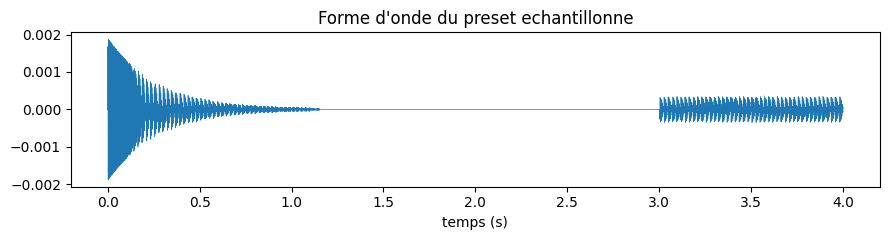

In [4]:
out = system.map({'params': theta})
audio = out['output']
print(f"Audio: {audio.shape}, peak={np.abs(audio).max():.4f}")

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.plot(np.linspace(0, len(audio)/16000, len(audio)), audio, linewidth=0.5)
ax.set_xlabel('temps (s)'); ax.set_title('Forme d\'onde du preset echantillonne')
plt.tight_layout(); plt.show()

display(Audio(audio, rate=16000))

### 2.3 Comportement (`DexedStatistics.map`) -- embedding 38D (6 ACTM + 32 TT)

Attention, cette cellule prend ~10-15s (calcul `ttb` inclus).

In [5]:
import time
t0 = time.time()
z = smap.map(out)
print(f"Calcul de Z: {time.time()-t0:.1f}s\n")

for name, val in zip(Z_FEATURE_NAMES, z['output']):
    print(f"  {name:22s} = {val:.4f}")

(64000,)
[16000]
F_computeDescriptorEnv	0.020214
F_representationFft	0.015555
F_computeDescriptorSpectrum	0.019252
F_computeDescriptorSpectrum	0.019928
F_representationHarmonic	2.058812
F_computeDescriptorHarmonic	0.085039
F_representationERB	0.746801
F_computeDescriptorSpectrum	0.003070
F_computeDescriptorSpectrum	0.002652
Calcul de Z: 4.4s

  ac_hardness            = 42.8980
  ac_depth               = 59.3791
  ac_brightness          = 41.4816
  ac_roughness           = 32.8195
  ac_warmth              = 56.0684
  ac_boominess           = 45.3982
  tt_SpecCent_IQR        = 176.6447
  tt_SpecCrest_med       = 101.2804
  tt_SpecCrest_IQR       = 88.9468
  tt_SpecDecr_med        = 0.0638
  tt_SpecDecr_IQR        = 0.0511
  tt_SpecFlat_med        = 0.0118
  tt_SpecFlat_IQR        = 0.7404
  tt_SpecKurt_med        = 69.9742
  tt_SpecKurt_IQR        = 93.3856
  tt_SpecRollOff_med     = 281.2500
  tt_SpecRollOff_IQR     = 34.7484
  tt_SpecSpread_med      = 234.9789
  tt_SpecSpread_IQR      

### 2.4 Mutation (`mutate()`) -- perturber un preset existant

`dexed.json` configure `explorer.config.mutator` avec `adtool.mutators.SpecificMutator`,
**pas** `GaussianMutator`. C'est un choix delibere, pas juste "celui par defaut" :

- `SpecificMutator.__call__(parameters, *, parameter_map)` ne fait qu'une chose : appeler
  `parameter_map.mutate(parameters)`. Il ne retient jamais le `parameter_map` (recu a chaque
  appel par l'explorer) -- ca le garde "checkpoint-safe" (rien de non-picklable dedans), au prix
  de ne rien savoir lui-meme sur la structure de Theta.
- `GaussianMutator` (l'alternative generique d'adtool) applique un bruit gaussien uniforme sur
  un vecteur plat -- adapte a des parametres homogenes/continus, mais **inadapte** aux 155
  parametres Dexed : ce sont des types heterogenes (continus, ordinaux a faible cardinalite,
  categoriels sans ordre) avec des echelles et des sensibilites tres differentes.

La vraie logique "un mutateur different par type de parametre" vit donc dans
`DexedParameterMap.mutate()`, qui delegue a `Dexed.get_similar_preset()`
(`spinvae2/synth/dexedbase.py:159-205`, reutilisee telle quelle depuis le pipeline de
data-augmentation du dataset humain) :

| Type de parametre | Traitement | Pourquoi |
|---|---|---|
| **Algorithme** (idx 4, 32 valeurs) | Cas special : `change_algorithm_to_similar()` | Pas un scalaire ordonne -- changer vers un algo "structurellement proche", pas du bruit |
| **OSC/LFO key sync, LFO wave** (2, 2, 6 valeurs) | Re-randomisation complete | Categoriel sans ordre, trop peu de valeurs pour que "bruit" veuille dire quelque chose |
| **OP mode** (ratio/fixed, 2 valeurs) | **Jamais mute** (`pass`) | Juge trop risque : peut rendre le son inaudible/aberrant |
| **L/R key scale** (4 valeurs, +/-lin/+/-exp) | Flip lin<->exp en preservant le signe | Categoriel structure (2 paires), pas un continu |
| **Tout le reste** (continus/ordinaux) | Bruit gaussien/triangle, **std proportionnel a 1/(cardinalite-1)** | Un parametre a 8 valeurs bouge rarement de plus d'un cran ; un parametre a 100 valeurs bouge finement |

C'est exactement le probleme souleve en discussion avec l'equipe adtool : un mutateur naif
(bruit uniforme sur les 144 dims apprenables) a du sens sur les parametres continus mais serait
absurde sur l'algorithme ou le LFO wave. `get_similar_preset()` evite ca, **et** reste coherent
avec la notion de "preset similaire" utilisee ailleurs dans spinvae2 (meme fonction que pour
generer les variations du dataset humain, `data/dexeddataset.py`).

**Limite ouverte** : le mode OP (ratio/fixed) n'est jamais explore par IMGEP une fois le preset
de depart echantillonne (choix delibere du code existant). A rediscuter si cette dimension
s'avere importante pour la couverture recherchee.

In [6]:
theta_mutated = pmap.mutate(theta)
preset_mutated = theta_mutated['dynamic_params']['preset']

diffs = sum(1 for (i1, v1), (i2, v2) in zip(preset, preset_mutated) if abs(v1 - v2) > 1e-9)
print(f"{diffs} / {len(preset)} parametres changes par mutate()")

# Breakdown par categorie (voir tableau ci-dessus) -- verifie concretement que le mutateur ne
# traite pas les 144 parametres apprenables de la meme facon.
from synth.dexed import Dexed as _Dexed
cat_indexes = set(_Dexed.get_categorical_params_indexes())
op_mode_indexes = {idx for idx in pmap.learnable_indices if idx > 32 and (idx - 32) % 22 == 0}
changed = {i for i, (v1, v2) in enumerate(zip(
    [v for _, v in preset], [v for _, v in preset_mutated])) if abs(v1 - v2) > 1e-9}

print(f"  algorithme (idx 4)         : {'change' if 4 in changed else 'inchange'}")
print(f"  OP mode (jamais mute)      : {len(op_mode_indexes & changed)} changes / {len(op_mode_indexes)} (doit etre 0)")
print(f"  categoriels (hors algo/OP) : {len((cat_indexes - op_mode_indexes - {4}) & changed)} "
      f"changes / {len(cat_indexes - op_mode_indexes - {4})}")
n_continuous = len(set(pmap.learnable_indices) - cat_indexes - {4})
print(f"  continus/ordinaux          : {len((set(pmap.learnable_indices) - cat_indexes - {4}) & changed)} "
      f"changes / {n_continuous}")

out_mutated = system.map({'params': theta_mutated})
display(Audio(out_mutated['output'], rate=16000))

103 / 155 parametres changes par mutate()
  algorithme (idx 4)         : inchange
  OP mode (jamais mute)      : 0 changes / 5 (doit etre 0)
  categoriels (hors algo/OP) : 10 changes / 22
  continus/ordinaux          : 93 changes / 122


## 3. Charger les decouvertes d'une experience IMGEP

Les experiences sauvegardent chaque decouverte dans un dossier `discoveries/`, avec :
- `discovery.json` (le preset + son embedding Z)
- `config.json`
- `visu.wav` (l'audio rendu, ecoutable directement)

**Note** : `RUN_DIR` pointe maintenant vers `run_2000_v2` (code a jour, termine le 2026-08-07,
1h20 pour 2000 decouvertes -- voir section 8 pour le detail du cout de calcul). `run_2000_38D`
(ancienne stack adtool, section 9) reste disponible pour comparaison historique. `run_500` a
ete lancee avant le passage a Z=38D -- ses decouvertes sont encore en 7D (ACTM seul). Le code
ci-dessous s'adapte automatiquement a la dimensionnalite trouvee (voir
`visualize_discoveries._dim_names`).

In [7]:
RUN_DIR = DEXED_ROOT / 'runs' / 'main'  # run a jour (2026-08-07) -- basculer sur 'run_2000_38D' pour l'ancienne stack
DISCOVERIES_DIR = RUN_DIR / 'discoveries'

from visualize_discoveries import load_discoveries, _dim_names

Z, order, wav_paths = load_discoveries(DISCOVERIES_DIR)
dim_names = _dim_names(Z.shape[1])
print(f"{len(Z)} decouvertes chargees depuis {DISCOVERIES_DIR}")
print(f"Z shape: {Z.shape} (dims: {dim_names})")

2000 decouvertes chargees depuis /u/anasynth/longeot/projects/spinvae2/adtool/dexed/run_2000_v2/discoveries
Z shape: (2000, 38) (dims: ['ac_hardness', 'ac_depth', 'ac_brightness', 'ac_roughness', 'ac_warmth', 'ac_boominess', 'tt_SpecCent_IQR', 'tt_SpecCrest_med', 'tt_SpecCrest_IQR', 'tt_SpecDecr_med', 'tt_SpecDecr_IQR', 'tt_SpecFlat_med', 'tt_SpecFlat_IQR', 'tt_SpecKurt_med', 'tt_SpecKurt_IQR', 'tt_SpecRollOff_med', 'tt_SpecRollOff_IQR', 'tt_SpecSpread_med', 'tt_SpecSpread_IQR', 'tt_SpecVar_med', 'tt_SpecVar_IQR', 'tt_F0_med', 'tt_F0_IQR', 'tt_HarmErg_IQR', 'tt_InHarm_med', 'tt_InHarm_IQR', 'tt_OddEvenRatio_med', 'tt_OddEvenRatio_IQR', 'tt_AmpMod', 'tt_Att', 'tt_Dec', 'tt_DecSlope', 'tt_EffDur', 'tt_FreqMod', 'tt_LAT', 'tt_RMSEnv_med', 'tt_RMSEnv_IQR', 'tt_TempCent'])


### 3.1 Progression de l'exploration dans Z (PCA)

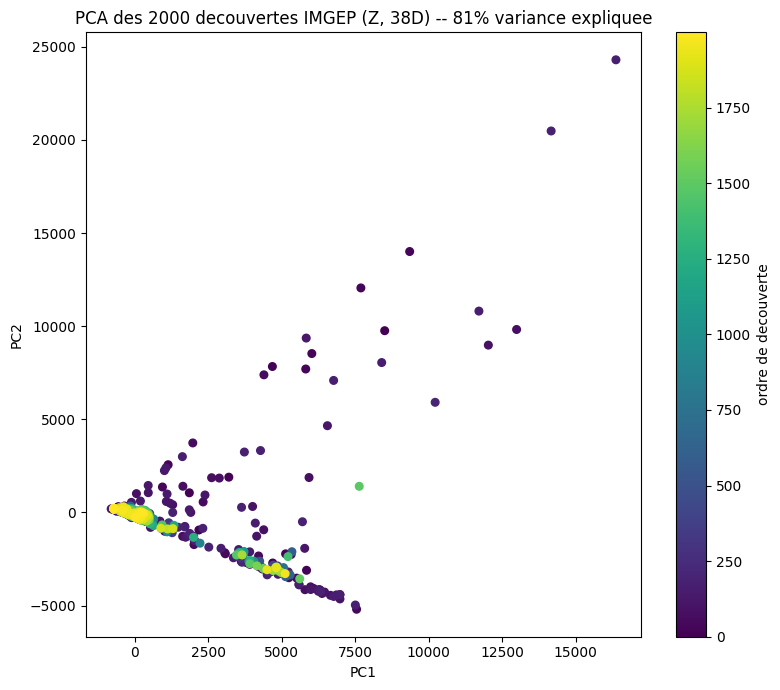

In [8]:
from sklearn.decomposition import PCA

Zc = Z - Z.mean(axis=0)
pca = PCA(n_components=2)
Zp = pca.fit_transform(Zc)

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(Zp[:, 0], Zp[:, 1], c=order, cmap='viridis', s=30)
plt.colorbar(sc, label='ordre de decouverte')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f"PCA des {len(Z)} decouvertes IMGEP (Z, {Z.shape[1]}D) -- "
             f"{100*pca.explained_variance_ratio_.sum():.0f}% variance expliquee")
plt.tight_layout(); plt.show()

On s'attend a voir les points progressivement s'etaler vers des zones nouvelles de
l'espace Z a mesure que l'ordre de decouverte (couleur) augmente -- c'est la signature de la
curiosite : IMGEP ne tire pas au hasard, il vise les zones les moins couvertes.

### 3.2 Structure de Z

Matrice de correlation par paire si Z a peu de dimensions (7D, ACTM seul), ou heatmap de
correlation si Z a beaucoup de dimensions (38D, canonique) -- une matrice de scatter 38x38
serait illisible.

Saved /tmp/tmpmvyg9ivr.png


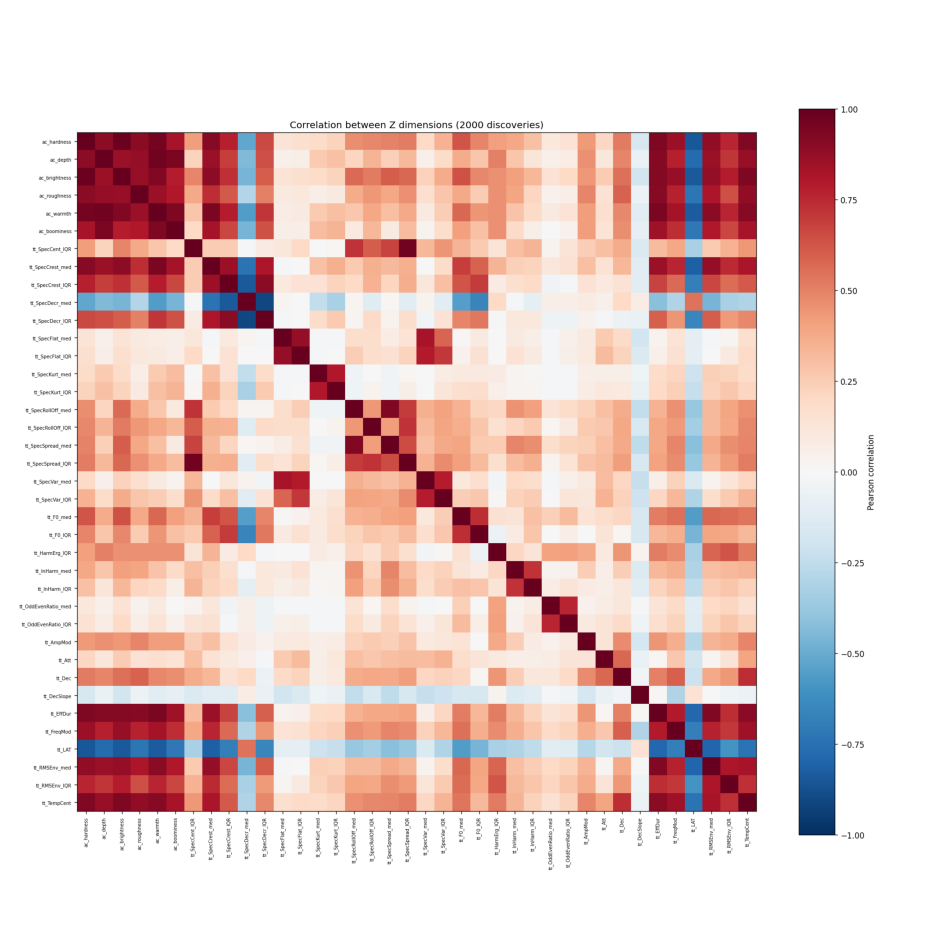

In [9]:
from visualize_discoveries import plot_scatter_matrix
import tempfile

with tempfile.NamedTemporaryFile(suffix='.png') as f:
    plot_scatter_matrix(Z, order, pathlib.Path(f.name), dim_names)
    display_img = plt.imread(f.name)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(display_img); ax.axis('off')
    plt.show()

### 3.3 Metriques de couverture

Si Z est bien en 38D (espace canonique), ces metriques sont **directement comparables** a la
baseline humaine calculee dans `CR audit dataset.md` (meme methodologie : distance moyenne au
plus proche voisin + occupation de grille, en natif). Si Z est en 7D (ACTM seul, anciennes
experiences), la comparaison n'est qu'indicative (espaces differents).

In [10]:
from visualize_discoveries import coverage_metrics

metrics = coverage_metrics(Z)
print(f"--- Couverture IMGEP (espace Z natif, {Z.shape[1]}D) ---")
for k, v in metrics.items():
    print(f"  {k}: {v}")

if Z.shape[1] == 38:
    print("\\n--- Baseline humaine (38D natif, cf. CR audit dataset.md section 2) ---")
    print("  Ratio distance NN dataset humain / uniforme aleatoire : 0.116")
    print("  (comparaison directe possible : meme espace de features)")
else:
    print("\\n--- Cette experience est en 7D (ACTM seul) : pas directement comparable "
          "a la baseline humaine 38D. Relancer une experience apres le passage a Z=38D. ---")

--- Couverture IMGEP (espace Z natif, 38D) ---
  n_discoveries: 2000
  mean_nn_distance: 137.13830865972753
  grid_occupancy: 0.26
  n_bins: 10
\n--- Baseline humaine (38D natif, cf. CR audit dataset.md section 2) ---
  Ratio distance NN dataset humain / uniforme aleatoire : 0.116
  (comparaison directe possible : meme espace de features)


## 4. Ecouter quelques decouvertes

In [11]:
N_LISTEN = 5
sample_idx = np.linspace(0, len(order) - 1, N_LISTEN).astype(int)

for i in sample_idx:
    wav_path = wav_paths[i]
    if wav_path is None:
        continue
    audio_d, sr_d = sf.read(wav_path)
    z_display = dict(zip(dim_names[:6], np.round(Z[i][:6], 1)))
    print(f"Decouverte #{order[i]} -- premieres dims Z = {z_display}")
    display(Audio(audio_d, rate=sr_d))

Decouverte #0 -- premieres dims Z = {'ac_hardness': np.float64(59.1), 'ac_depth': np.float64(17.8), 'ac_brightness': np.float64(72.7), 'ac_roughness': np.float64(0.0), 'ac_warmth': np.float64(36.2), 'ac_boominess': np.float64(7.8)}


Decouverte #499 -- premieres dims Z = {'ac_hardness': np.float64(0.0), 'ac_depth': np.float64(0.0), 'ac_brightness': np.float64(0.0), 'ac_roughness': np.float64(0.0), 'ac_warmth': np.float64(0.0), 'ac_boominess': np.float64(0.0)}


Decouverte #999 -- premieres dims Z = {'ac_hardness': np.float64(52.2), 'ac_depth': np.float64(67.7), 'ac_brightness': np.float64(60.1), 'ac_roughness': np.float64(53.6), 'ac_warmth': np.float64(49.4), 'ac_boominess': np.float64(27.9)}


Decouverte #1499 -- premieres dims Z = {'ac_hardness': np.float64(0.0), 'ac_depth': np.float64(0.0), 'ac_brightness': np.float64(0.0), 'ac_roughness': np.float64(0.0), 'ac_warmth': np.float64(0.0), 'ac_boominess': np.float64(0.0)}


Decouverte #1999 -- premieres dims Z = {'ac_hardness': np.float64(0.0), 'ac_depth': np.float64(0.0), 'ac_brightness': np.float64(0.0), 'ac_roughness': np.float64(0.0), 'ac_warmth': np.float64(0.0), 'ac_boominess': np.float64(0.0)}


## 5. Visualiseur web (`adtool.user_tools.visu.server`)

```bash
cd ~/projects/spinvae2/adtool/dexed
python -m adtool.user_tools.visu.server --discoveries runs/main/discoveries
```

Sert sur `127.0.0.1:8765` (port fixe, pas d'option). Si vous etes sur une VM distante (Windows
en local), il faut un tunnel : soit VS Code Remote-SSH (`Ports` -> `Forward a Port` -> `8765`),
soit `ssh -L 8765:127.0.0.1:8765 user@host` manuel.

### Trois bugs trouves et corriges en le testant sur `run_2000_38D`

**1. NaN/Inf dans Z -> `Number of discoveries: 0`.** Le viewer rejette toute decouverte dont
l'embedding contient un NaN/Inf (`_valid_embedding` dans `adtool.user_tools.visu.coordinates`).
Sur `run_2000_38D`, **1376/2000 decouvertes (69%)** avaient un NaN quelque part dans leurs 38
dims. Cause : `tt_InHarm` divise directement par F0 sans protection
(`ttb_peeters/peeTimbreToolbox.py:587`) et `tt_OddEvenRatio` peut deborder `float32` meme avec
un epsilon au denominateur (`:598`) -- les deux supposent un son clairement pitche pour que le
suivi de partiels (SWIPE) fonctionne. Le dataset humain est toujours musical/pitche (jamais de
NaN ou presque) ; IMGEP genere plein de sons bruites/percussifs/non-pitches ou l'estimation de
F0 echoue. Fix : `DexedStatistics._calc_static_statistics` fait maintenant
`np.nan_to_num(embedding, nan=0.0, posinf=0.0, neginf=0.0)` avant de retourner -- toutes les
decouvertes de `run_2000_v2` (genere apres ce fix) sont deja finies nativement, 0 NaN a nettoyer.

**2. `.wav` non reconnu par le viewer -> toujours 0 decouvertes meme apres le fix NaN.**
`VALID_VISUAL_SUFFIXES = (".mp4", ".png")` est code en dur dans le viewer -- un `.wav` seul
n'est pas resolu comme "visuel" et la decouverte est droppee. Fix : `DexedSimulation.render()`
genere maintenant aussi une image PNG (forme d'onde) en plus du `.wav`
(`return [(png_bytes, "png"), (wav_bytes, "wav")]`) -- le viewer utilise le PNG comme vignette,
le `.wav` reste disponible pour l'ecoute directe depuis le dossier.

**3. Le fix precedent cassait les plots de ce notebook.** La premiere version du fix PNG faisait
`matplotlib.use("Agg")` en tete de `systems/Dexed.py` (backend headless, necessaire pour un run
d'experience non-interactif). Probleme : des que ce module est importe dans **ce notebook**
(cellule "2. Les 3 briques"), ca mute le backend matplotlib de tout le kernel Jupyter -- les
`plt.show()` suivants (PCA, matrice de scatter) ne produisent alors plus aucune image, sans
erreur. Fix : `render()` utilise maintenant l'API orientee-objet de matplotlib
(`matplotlib.figure.Figure` + `FigureCanvasAgg` directement) plutot que `pyplot`, qui ne
necessite aucune selection globale de backend. **Si les plots de ce notebook restent vides**,
c'est que le kernel a deja importe l'ancienne version en memoire -- redemarrer le kernel
(pas juste re-executer les cellules) pour repartir d'un etat matplotlib propre.

## 6. Comparaison Random / Human / IMGEP

Trois jeux de decouvertes pour repondre a "IMGEP explore-t-il mieux que le hasard, et
comment se situe-t-il par rapport au dataset humain ?" :

| Jeu | n | Comment | Duree reelle |
|---|---|---|---|
| **Human** | 30145 | Export de `raw_timbre_features_ttb.df.pickle` (dataset humain existant) vers le format `discoveries/*/discovery.json` attendu par adtool (`{"output": [...38 raw features...], "metadata": {"run_idx": i}}`) | quelques minutes (juste de l'ecriture de fichiers) |
| **Random** | 2000 | `dexed_random_baseline.json` : `bootstrap_size >= nb_iterations` -> aucune mutation ne se declenche jamais, echantillonnage i.i.d. pur (`parameter_map.sample()`) | **~12 min** en parallelisant sur 16 processus |
| **IMGEP** | `run_2000_38D` (2000, ancienne stack) + **`run_2000_v2`** (2000, code a jour -- reference principale de ce notebook) | Run continu normal (bootstrap puis mutation dirigee par but) | `run_2000_38D` : ~7h (sequentiel, ancienne stack). `run_2000_v2` : **1h20 reelles** (15:57 -> 17:18, 2026-08-07), cout mesure 5.8s/eval |

### Random baseline : parallelisable, IMGEP non

Le random baseline n'a **aucune dependance sequentielle** (chaque tirage est independant) --
on peut lancer N processus independants, chacun avec un seed different et son propre
`save_location`, sans rien changer au resultat. Teste d'abord sur 3 processus (valider que
DawDreamer tient le coup en multi-instance -- oui, aucun probleme), puis passe a 16 :
`random_2000_shard01/` a `random_2000_shard16/`, 125 iterations chacun, ~12 minutes au total
(48 coeurs disponibles, machine quasi inactive).

**IMGEP, lui, ne se parallelise pas de la meme facon** : chaque etape depend de l'historique
cumule (choix du but, recherche du plus proche voisin). On pourrait lancer plusieurs IMGEP
*independants* en parallele (plusieurs trajectoires courtes plutot qu'une longue), mais ca
change la dynamique d'exploration (moins de profondeur d'historique par run) -- pas equivalent
a un seul run continu de 2000 comme `run_2000_38D`. `run_2000_v2` reste donc un run continu
classique, juste avec la stack de code a jour -- et s'est avere bien plus rapide que redoute
(1h20 au lieu des 3-3.5h estimees, voir section 8).

### Fusionner les shards random (a executer une fois avant l'analyse)

Le loader d'adtool (`load_discovery_set`) scanne recursivement (`Path.rglob("discovery.json")`)
-- mais **ne suit pas les liens symboliques** (contrairement a `find`, piege rencontre en
essayant d'abord des symlinks). Les 16 shards sont donc fusionnes en vrais hardlinks
(instantane, aucune duplication d'espace disque, meme systeme de fichiers) dans
`runs/random/combined/discoveries/` -- commande dans la cellule suivante.

### Lancer l'analyse comparative

`dexed_human_comparison_analysis.json` utilise `analysis_projection.identity_z_projection`
(fonction locale, `dataset.outputs` = Z brut directement, pas besoin de projection puisque Z
**est** deja le comportement) avec `Comparison1DModule` (densites par dimension) et
`Comparison2DModule` (scatter sur quelques paires de dimensions). Deja teste et valide (ecrit
dans `analysis_runs/`) -- commande dans la cellule suivante, a lancer depuis un terminal.


```bash
mkdir -p runs/random/combined/discoveries
for i in $(seq -w 1 16); do
  cp -al "random_2000_shard${i}/discoveries/"* runs/random/combined/discoveries/
done
```

```bash
python -m adtool.runners.run_analysis \
  runs/main/discoveries \
  runs/human_baseline/discoveries runs/random/combined/discoveries \
  --config_file dexed_human_comparison_analysis.json \
  --primary_label IMGEP --comparison_label human --comparison_label random
```

## 7. Bornes plausibles, couverture de grille, et diversite (Vendi Score)

`coverage_diversity.py` (nouveau module local) repond a deux questions :

**Ou sont les limites de l'espace d'observation Z ?** Pas de bornes theoriques propres pour la
plupart des `tt_*` (contrairement a un ratio borne [0,1] par exemple), et le min/max brut est
fragile a un seul outlier (ex. les valeurs mises a 0.0 par le fix NaN ci-dessus). Solution :
`compute_plausible_bounds()` combine plusieurs jeux de decouvertes (Random+Human+IMGEP
ensemble) et prend un intervalle de **percentiles** (0.5%-99.5% par defaut) par dimension --
robuste aux valeurs extremes, et defini une seule fois pour que Random/Human/IMGEP (et plus
tard l'etude SpinVAE2) restent comparables sur les memes bornes fixes. `np.nanpercentile` est
utilise explicitement (pas `np.percentile`) : le dataset humain brut contient 3/30145 lignes
avec un NaN (negligeable, a ignorer plutot qu'imputer).

**A quel point chaque jeu est-il divers ?** Deux mesures complementaires :
- `grid_coverage()` : fraction de cellules occupees dans une grille (sur un sous-ensemble de
  dimensions -- 38D pleine grille est intractable). Sensible a *n* (plus de points = plus de
  cellules touchees mecaniquement), donc a interpreter avec precaution entre jeux de tailles
  tres differentes (Human=30145 vs Random/IMGEP=2000).
- `vendi_score()` (Friedman & Dieng, 2022) : mesure de diversite **sans reference/labels**,
  `VS = exp(-sum(p*log(p)))` ou `p` sont les valeurs propres de `K/n` (matrice de similarite
  cosine, `k(x,x)=1`). Contrairement a `grid_coverage`, se comporte bien pour comparer des jeux
  de *n* different **si on sous-echantillonne a la meme taille avant de comparer** (le Vendi
  Score reste sensible a *n*, comme la plupart des mesures de diversite). Cosine choisi plutot
  que RBF (pas de parametre de bande passante a regler) -- mais necessite un z-score prealable
  des features (echelles tres heterogenes : F0 en Hz vs ratios en [0,1], sinon les dimensions a
  grande echelle dominent completement la similarite cosine). O(n^3) (decomposition en valeurs
  propres) -- sous-echantillonner les gros datasets (30145 humains -> intractable tel quel,
  quelques heures) avant d'appeler la fonction.

### Resultats (Random vs Human vs **IMGEP=`run_2000_v2`**, n=2000 chacun, 2026-08-07)

| | grid_coverage (3 dims ACTM, 10 bins) | Vendi Score (cosine, n=2000) |
|---|---|---|
| Random | 12.9% | **15.16** |
| Human | 38.4% (n=30145, pas directement comparable) | 9.50 |
| IMGEP | 12.3% | **4.24** |

**Resultat confirme, pas un artefact de code** : calcule une premiere fois sur `run_2000_38D`
(ancienne stack adtool, Vendi=4.82), puis re-calcule ici sur `run_2000_v2` (code exact de ce
notebook, Vendi=4.24 -- **encore plus bas**). Ce n'est donc pas du a la refonte d'infrastructure
d'adtool (section 9) : IMGEP est bien, de facon reproductible, moins divers que le random pur
sur ce probleme, sur les deux mesures. Deux hypotheses pas encore tranchees : (1) le random pur
produit une diversite "facile" (presets casses/bruites tres differents les uns des autres, mais
pas forcement interessants), ou (2) la mutation IMGEP se resserre trop autour des zones deja
decouvertes (recherche de but/mutation pas assez exploratoire). La visu d'evolution des
mutations Theta (section 10, pas encore codee) est la prochaine piste naturelle pour trancher.

In [13]:
from coverage_diversity import load_z_matrix, compute_plausible_bounds, grid_coverage, vendi_score

# Z est deja run_2000_v2 (voir section 3, RUN_DIR pointe dessus)
Z_random = load_z_matrix('random_2000_shard01/discoveries')
for i in range(2, 17):
    Z_random = np.concatenate([Z_random, load_z_matrix(f'random_2000_shard{i:02d}/discoveries')], axis=0)
Z_human_full = load_z_matrix('runs/human_baseline/discoveries')

def clean(M):
    return M[~np.isnan(M).any(axis=1)]
Z_imgep_c, Z_human_c, Z_random_c = clean(Z), clean(Z_human_full), clean(Z_random)
print(f'NaN rows dropped: IMGEP={len(Z)-len(Z_imgep_c)} human={len(Z_human_full)-len(Z_human_c)} random={len(Z_random)-len(Z_random_c)}')

bounds = compute_plausible_bounds([Z, Z_human_full, Z_random], Z_FEATURE_NAMES)

print()
print('--- grid_coverage (dims 0,1,2 = ac_hardness/depth/brightness, 10 bins/dim) ---')
for label, M in [('random', Z_random), ('human', Z_human_full), ('IMGEP (run_2000_v2)', Z)]:
    cov = grid_coverage(M, bounds, Z_FEATURE_NAMES, dimensions=[0, 1, 2], bins_per_dim=10)
    print(f'  {label:20s} (n={len(M):5d}): {cov*100:.1f}%')

print()
print('--- Vendi Score (cosine, z-score sur reference combinee, n identique) ---')
rng = np.random.default_rng(0)
n = min(len(Z_imgep_c), len(Z_human_c), len(Z_random_c))
subs = {
    'random': Z_random_c[rng.choice(len(Z_random_c), n, replace=False)],
    'human':  Z_human_c[rng.choice(len(Z_human_c), n, replace=False)],
    'IMGEP (run_2000_v2)':  Z_imgep_c[rng.choice(len(Z_imgep_c), n, replace=False)] if len(Z_imgep_c) > n else Z_imgep_c,
}
ref = np.concatenate(list(subs.values()), axis=0)
mu, sigma = ref.mean(axis=0), ref.std(axis=0)
sigma[sigma == 0] = 1.0
for label, M in subs.items():
    print(f'  {label:20s} (n={len(M)}): {vendi_score((M - mu) / sigma):.2f}')

NaN rows dropped: IMGEP=0 human=3 random=0
compute_plausible_bounds: 65 NaN values found across the combined dataset (34145 rows) -- ignored via nanpercentile, not imputed.

--- grid_coverage (dims 0,1,2 = ac_hardness/depth/brightness, 10 bins/dim) ---
  random               (n= 2000): 12.9%
  human                (n=30145): 38.4%
  IMGEP (run_2000_v2)  (n= 2000): 12.3%

--- Vendi Score (cosine, z-score sur reference combinee, n identique) ---
  random               (n=2000): 15.16
  human                (n=2000): 9.50
  IMGEP (run_2000_v2)  (n=2000): 4.24


## 8. Peut-on accelerer `ttb` ? (investigation, conclusion : pas vraiment necessaire)

Le Readme annoncait ~10-12s/evaluation sur des presets aleatoires. Profiling reel :
`F_representationHarmonic` (estimation de F0 via SWIPE, `ttb_peeters/swipep.py`) domine a elle
seule (~80-90% du temps d'un appel `compute_tt_features`).

**Deux pistes de parallelisation envisagees, toutes deux ecartees :**
- *Paralleliser la boucle interne de SWIPE* (4 iterations sur des echelles de fenetre
  differentes, `plim=[50,500]`) : a premiere vue independantes, mais en fait **dependance
  sequentielle cachee** -- `fERBs` est tronque progressivement a chaque iteration
  (`fERBs = fERBs[i_tmp:]`). Paralleliser sans precaution changerait le resultat ; le faire
  correctement demande de recalculer l'index de troncature par iteration independamment (faisable
  mathematiquement mais pas trivial a valider), pour un gain limite (seulement 4 iterations).
- *Paralleliser SWIPE contre le reste de `ttb`* (Env/Spectral/ERB, independants entre eux) :
  comme Harmonic domine a 80-90%, le reste attend de toute facon -- gain marginal (~x1.2).

**Piste alternative testee et abandonnee** : degrader la resolution SWIPE (`dt` 0.01->0.02,
`dlog2p` 1/48->1/24) donnait un gain x2-4 avec une derive de F0 mediane generalement <2%
(jusqu'a ~9% sur un cas isole) -- mais **abandonnee car pas necessaire** une fois le vrai cout
mesure (voir ci-dessous), pour eviter de degrader la precision d'un module deja valide contre
MATLAB pour un gain qui ne s'averait plus utile.

**Ce qui a resolu le probleme : le vrai cout mesure etait bien plus bas que documente.**
Un shard random (125 evaluations) a mis 725s en pratique, soit **5.8s/evaluation reel**, pas
10-12s -- l'estimation du Readme datait probablement d'avant les fixes NumPy2/librosa de cette
session, ou d'une machine plus chargee. A ce taux, `run_2000_v2` (2000 iterations continues) a
pris **1h20 reelles** (15:57 -> 17:18), tres en dessous des 3-3.5h estimees avec ce meme taux --
suffisant pour ne pas avoir besoin de degrader la precision.

**Le vrai levier de vitesse trouve et utilise : paralleliser entre evaluations, pas dedans.**
Le random baseline n'a aucune dependance sequentielle -- 16 processus independants (16 coeurs
sur 48 disponibles) ont fait tourner les 2000 evaluations en ~12 minutes au lieu de ~3h
sequentielles. Voir section 6.

## 9. Ce qui a change dans adtool depuis `run_2000_38D`

`run_2000_38D` a ete genere avec l'ancienne branche locale d'adtool (commit `2dcea81`). Depuis,
la branche a ete rebasee sur `origin/main` (upstream flowersteam/adtool a avance de plusieurs
dizaines de commits). `git diff` sur `adtool/explorers/IMGEPExplorer.py` entre les deux montre
une refonte d'infrastructure, mais **l'algorithme d'exploration reste le meme conceptuellement** :

| | Ancien (`run_2000_38D`) | Nouveau (`run_2000_v2`, ce notebook) |
|---|---|---|
| Recherche du but le plus proche | `SaveWrapper.buffer` en memoire + `np.argmin(norm(...))` | `HistoryStore.nearest()` -- streaming par chunks, compatible checkpoints/resume |
| Config mutateur/maps | Chaines a plat (`"mutator": "specific"`, `"behavior_map": "chemin.string"`) | Schema imbrique `{"path": ..., "config": ...}` (voir TUTORIAL) |
| Boucle bootstrap -> mutation | Identique : `equil_time`/`bootstrap_size` puis but aleatoire -> 1-plus-proche-voisin -> `mutate()` | Identique |

`run_2000_v2` a ete lance avec le code exact de ce notebook, comme verification independante --
et **confirme** le resultat Vendi Score de la section 7 (4.24, proche du 4.82 de `run_2000_38D`,
toujours nettement sous le random). La refonte d'infrastructure n'explique donc pas le resultat
surprenant : c'est une propriete reelle de l'algorithme/mutateur sur ce probleme, pas un artefact
de version.

## 10. Evolution des mutations (Theta)

Pas de lien de filiation explicite sauvegarde dans `discovery.json` (le `source_policy` utilise
par `suggest_trial()` n'est pas persiste) -- donc pas de vraie "chaine de mutation" a tracer.
Mais l'ordre `run_idx` donne un proxy simple et suffisant : la **distance Theta entre
decouvertes consecutives** (L2 sur les 155 dims) montre a quel point chaque etape bouge par
rapport a la precedente, phase bootstrap vs phase mutation.

Theta: (2000, 155), 200 pas de bootstrap / 2000


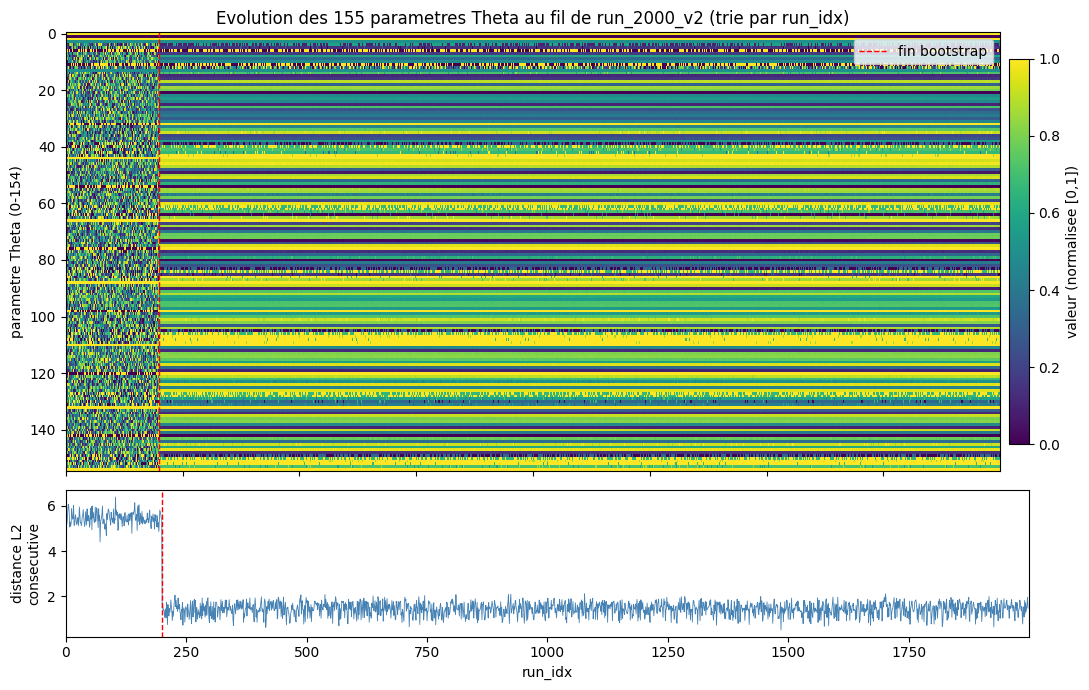


Distance Theta consecutive (L2, 155 dims):
  bootstrap   (idx<200): mean=5.449
  exploration (idx>=200): mean=1.452
  ratio: 3.75x

Parametres quasi-constants (<=3 valeurs uniques / 2000): 19 / 155


In [14]:
theta_files = sorted((RUN_DIR / 'discoveries').glob('*/discovery.json'))
rows = []
for f in theta_files:
    d = json.load(f.open())
    theta = np.array([v for _, v in d['params']['dynamic_params']['preset']], dtype=float)
    rows.append((d['metadata']['run_idx'], d['equil'], theta))
rows.sort(key=lambda r: r[0])
theta_run_idx = np.array([r[0] for r in rows])
theta_equil = np.array([r[1] for r in rows])
Theta = np.stack([r[2] for r in rows])
n_bootstrap = int(theta_equil.sum())
print(f"Theta: {Theta.shape}, {n_bootstrap} pas de bootstrap / {len(theta_equil)}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

im = ax1.imshow(Theta.T, aspect='auto', cmap='viridis', interpolation='nearest')
ax1.axvline(n_bootstrap, color='red', linewidth=1, linestyle='--', label='fin bootstrap')
ax1.set_ylabel('parametre Theta (0-154)')
ax1.set_title(f'Evolution des 155 parametres Theta au fil de {RUN_DIR.name} (trie par run_idx)')
ax1.legend(loc='upper right')
plt.colorbar(im, ax=ax1, label='valeur (normalisee [0,1])', fraction=0.02, pad=0.01)

consec_dist = np.linalg.norm(np.diff(Theta, axis=0), axis=1)
ax2.plot(consec_dist, linewidth=0.6, color='steelblue')
ax2.axvline(n_bootstrap, color='red', linewidth=1, linestyle='--')
ax2.set_ylabel('distance L2\nconsecutive')
ax2.set_xlabel('run_idx')
plt.tight_layout(); plt.show()

print(f"\nDistance Theta consecutive (L2, 155 dims):")
print(f"  bootstrap   (idx<{n_bootstrap}): mean={consec_dist[:n_bootstrap-1].mean():.3f}")
print(f"  exploration (idx>={n_bootstrap}): mean={consec_dist[n_bootstrap-1:].mean():.3f}")
print(f"  ratio: {consec_dist[:n_bootstrap-1].mean() / consec_dist[n_bootstrap-1:].mean():.2f}x")

n_unique_per_param = np.array([len(np.unique(np.round(Theta[:, i], 4))) for i in range(Theta.shape[1])])
print(f"\nParametres quasi-constants (<=3 valeurs uniques / {len(Theta)}): {(n_unique_per_param<=3).sum()} / 155")

### Explication du resultat "IMGEP moins divers que Random" (section 7)

Calcule sur `run_2000_v2` :

- **Distance Theta consecutive : bootstrap ~5.45, exploration ~1.45 -- ratio 3.75x.** Chaque pas
  de mutation deplace le preset ~3.75x moins qu'un tirage aleatoire independant. C'est attendu
  et voulu (section 2.4 : `get_similar_preset()` fait volontairement de petits pas, pas un
  nouveau tirage complet) -- mais ca implique mecaniquement que deux decouvertes consecutives
  se ressemblent beaucoup plus en phase d'exploration qu'en phase bootstrap.
- **19/155 parametres quasi-constants sur les 2000 decouvertes.** Coherent avec les 11 indices
  fixes (filtre/tune/middle C, jamais explores) + les 5 indices "OP mode" (jamais mutes,
  section 2.4) = 16 attendus ; les 3 de plus sont probablement l'algorithme (idx 4, mute
  rarement via son cas special) et 1-2 categoriels a faible probabilite de changement.

**Interpretation** : ce n'est pas un bug, c'est la consequence directe et attendue du design
"mutation locale autour du plus proche voisin d'un but" -- IMGEP echange delibermement de la
diversite brute contre de la precision locale autour des zones deja decouvertes (hill-climbing
guide par le but, pas un redemarrage aleatoire a chaque etape). Random, en tirant i.i.d. a
chaque fois, couvre mecaniquement tout l'espace discretise de facon uniforme -- plus "divers"
au sens Vendi Score/grid_coverage, mais sans aucune notion de ce qui est interessant ou pas.

**Question ouverte, pas tranchee ici** : est-ce que ce compromis est bien calibre pour cette
tache (`variation=2` fixe, section 2.4) ? Un pas de mutation plus grand rapprocherait sans
doute IMGEP du random en diversite brute, mais reduirait sa capacite a affiner precisement
autour d'un but -- l'objectif d'IMGEP n'est pas "etre aussi divers que possible", mais "couvrir
les buts". Les deux mesures (Vendi Score, grid_coverage) ne captent que la diversite brute, pas
la pertinence des buts couverts -- une metrique de couverture *des buts demandes* (et pas
seulement de l'espace atteint) manque encore pour trancher.

## 11. Etat actuel et prochaines etapes (2026-08-07)

**Fait :**
- Viewer web teste et corrige (NaN/Inf -> `nan_to_num`, `.wav` non reconnu -> ajout d'un PNG
  forme d'onde au rendu, backend matplotlib qui cassait ce notebook -> API objet Figure) --
  section 5.
- Dataset humain exporte au format `discoveries/` (30145 presets) -- section 6.
- Random baseline genere (2000, parallelise sur 16 processus, ~12 min) -- section 6.
- **`run_2000_v2` termine** : 2000 decouvertes, code a jour, **1h20 reelles** (bien plus rapide
  que redoute) -- section 6, 8.
- `coverage_diversity.py` : bornes plausibles (percentiles), `grid_coverage`, Vendi Score --
  section 7. **Resultat confirme sur deux runs independants** : IMGEP moins divers que le
  random pur (Vendi 4.24 sur `run_2000_v2` vs 15.16 pour random, vs 4.82 sur l'ancien
  `run_2000_38D`) -- pas un artefact de version d'adtool (section 9).
- Investigation acceleration `ttb` : pas de vrai levier de parallelisation interne trouve, mais
  le vrai cout mesure (5.8s/eval) etait deja bien plus bas que documente -- section 8.
- Mutateur explique et verifie en detail : `SpecificMutator` + `get_similar_preset()`, quand une
  mutation se declenche (`bootstrap_size` vs `equil_time`), et sa "puissance" (`variation=2`,
  codee en dur, pas exposee en config aujourd'hui) -- section 2.4.

**A faire :**
- Lancer `run_analysis` (commande section 6) -- comparaison Comparison1D/2D dans le viewer, en
  plus des metriques numeriques deja calculees ici.
- **Priorite** : comprendre pourquoi IMGEP < Random en diversite, confirme sur deux runs
  independants -- la visu d'evolution des mutations Theta (section 10, pas encore codee) est la
  premiere piste pour voir si la mutation se resserre trop autour des zones deja decouvertes.
- Rediger la conclusion de `imgep_coverage_vs_human_baseline.ipynb` (cellules deja executees,
  resultats disponibles -- ratio NN/uniforme quasi identique humain vs IMGEP, ~0.10-0.11).
- Decider si le mode OP (jamais mute, section 2.4) doit rester fige ou etre reactive.
- Traiter le biais `tt_F0_med` (voir audit dataset, section 5) avant toute analyse qui en
  depend fortement.
- Etude 2 (SpinVAE2 dans la boucle, 4 variantes de VAE x 2 methodes de parameter_map) : pas
  commencee, en attente de clarifier l'etat des checkpoints VAE disponibles.


## 12. Recapitulatif complet des hyperparametres et resultats (pour discussion avec des chercheurs)

### Espace de parametres (Theta) et de comportement (Z)

| | Valeur |
|---|---|
| Theta (parametres synth) | 155 parametres bruts Dexed (DX7), dont **144 apprenables** / 11 fixes (filtre/tune, middle C, 6 switches marche/arret operateurs) |
| Z (comportement) | **38 dimensions** : 6 ACTM (AudioCommons Timbral Models) + 32 TT (TimbreToolbox, port Python `ttb_peeters`, sans MATLAB) |
| Note MIDI de reference | pitch=56, velocity=75 (fixe, identique a tout le dataset spinvae2) |
| Rendu audio | `output_Fs=16000` Hz, `midi_note_duration_s=3.0`, `render_duration_s=4.0` -- via DawDreamer (moteur VST offline) |

### Config experiment (commune aux 3 runs sauf mention)

| Cle | IMGEP (`run_2000_v2`) | Random (`random_2000_shard*`) |
|---|---|---|
| `save_frequency` | 100 | 100 |
| `bootstrap_size` | **200** (10% de 2000) | **125 = nb_iterations du shard** (bootstrap couvre tout -> jamais de mutation) |
| `discoveries_cache_size` | -1 (historique complet en RAM) | -1 |
| `equil_time` (explorer) | 1 (largement domine par `bootstrap_size`, quasi sans effet propre) | 1 (sans effet, bootstrap_size domine tout le run) |
| `parameter_map.seed` | 0 | 101-116 (test) / 201-216 (run final, un seed distinct par shard) |
| nb_iterations | 2000 (1 run continu) | 2000 total (16 x 125, processus independants paralleles) |

### Mutateur (IMGEP uniquement -- random n'en utilise jamais)

- `explorer.config.mutator` = `adtool.mutators.SpecificMutator` (delegue a `parameter_map.mutate()`, pas de bruit generique)
- Politique de selection : but tire uniformement dans les bornes de Z deja decouvertes (`behavior_map.sample()`) -> **1-plus-proche-voisin exact** (L2) dans l'historique (`HistoryStore.nearest()`, k=1) -> mutation de CE preset precis
- Puissance de mutation : `Dexed.get_similar_preset(preset, variation=2, ...)` -- **`variation=2` fixe, code en dur** dans `DexedParameterMap.mutate()` (`maps/DexedParameterMap.py:101`), **pas expose en config JSON aujourd'hui**. Pas de decay ni de programme (meme puissance du 1er au 2000e pas post-bootstrap).
- Traitement par type de parametre dans `get_similar_preset()` (`spinvae2/synth/dexedbase.py:159-205`) :

| Type | Cardinalite typique | Traitement |
|---|---|---|
| Algorithme (idx 4) | 32 | Cas special `change_algorithm_to_similar()` |
| OSC/LFO key sync, LFO wave | 2 / 2 / 6 | Re-randomisation complete |
| OP mode (ratio/fixed) | 2 | **Jamais mute** (`pass`) |
| L/R key scale | 4 | Flip lin<->exp, signe preserve |
| Continus/ordinaux (majorite) | ~100 (quantifies, pas float libre) | Bruit gaussien/triangle, std ~ 1/(cardinalite-1) |

### `ttb` (TimbreToolbox) -- cout et parametres SWIPE (estimation F0)

- `swipep(audio, Fs, plim=[50,500], dt=0.01, dlog2p=1/48, dERBs=0.1, woverlap=0.2, sTHR=-inf)` -- non expose en config, code en dur dans `ttb_peeters/peeTimbreToolbox.py:763`
- Cout mesure : **5.8s/evaluation** en moyenne (dominee a 80-90% par `F_representationHarmonic`/SWIPE)
- Piste de reduction testee (`dt`->0.02, `dlog2p`->1/24, gain x2-4, derive F0 mediane <2% generalement) : **non appliquee**, jugee non necessaire vu le cout reel

### Datasets generes

| Jeu | n | Duree reelle | Fichier config |
|---|---|---|---|
| Human (reference) | 30145 (3 lignes NaN, negligeable) | -- (export d'un pickle existant) | -- |
| Random | 2000 (16 x 125) | ~12 min (parallele, 16 coeurs) | `dexed_random_shard01-16.json` (seeds 201-216) |
| IMGEP `run_2000_38D` | 2000 (1995 utilisables, 5 dossiers incomplets) | ~7h (ancienne stack adtool, sequentiel) | config plate, `mutator: "specific"` (ancien schema) |
| IMGEP `run_2000_v2` | 2000 | **1h20 reelles** (15:57->17:18, 2026-08-07) | `dexed_imgep_2000_v2.json` |

### Resultats de diversite (section 7, confirmes sur 2 runs IMGEP independants)

| Metrique | Random (n=2000) | Human (n=2000, sous-echantillon de 30145) | IMGEP `run_2000_38D` | IMGEP `run_2000_v2` |
|---|---|---|---|---|
| Vendi Score (cosine, z-score) | **15.16** (17.28 sur le 1er calcul) | 9.50 (7.05 sur le 1er calcul -- variance d'echantillonnage) | 4.82 | **4.24** |
| grid_coverage (3 dims ACTM, 10 bins) | 12.9% | 38.4% (n=30145, pas comparable directement) | 10.7% | 12.3% |

### Resultats sur Theta (section 10, `run_2000_v2`)

- Distance L2 consecutive (155 dims) : bootstrap **5.45** vs exploration/mutation **1.45** -- **ratio 3.75x**
- **19/155 parametres quasi-constants** sur les 2000 decouvertes (coherent avec 11 fixes + 5 OP-mode jamais mutes + ~3 autres a faible probabilite de changement)

### Interpretation actuelle (a challenger)

Le pas de mutation (`variation=2` fixe) deplace ~3.75x moins qu'un tirage aleatoire independant
-> IMGEP echange de la diversite brute (mesuree par Vendi Score / grid_coverage) contre de la
precision locale autour des buts deja atteints (hill-climbing guide, pas de redemarrage
aleatoire a chaque pas). Question ouverte : ce compromis est-il bien calibre pour cette tache,
et les deux metriques utilisees (diversite brute) sont-elles les bonnes pour juger un algorithme
dont l'objectif est de couvrir des *buts*, pas d'etre maximalement disperse ?


## 13. Retour litterature (2026-08-10) -- pourquoi le resultat section 7 est en tension avec la theorie IMGEP

Consultation externe (chercheurs) sur le resultat "IMGEP moins divers que Random" (section 7).
Synthese :

### L'argument theorique standard, et pourquoi il predit l'inverse de nos resultats

L'avantage attendu d'IMGEP sur Random repose sur la **redondance de la carte Theta->Z** :
quand beaucoup de configurations de parametres differentes produisent le meme comportement,
Random gaspille son budget a re-decouvrir les zones deja redondantes, alors qu'IMGEP (buts
tires uniformement dans Z deja atteint) devrait couvrir les differents niveaux de redondance
de facon plus egale. C'est explicite dans la lignee Oudeyer/Moulin-Frier (papiers reseaux de
regulation genique, meme lignee que la these d'Etcheverry) : la strategie orientee-but est
"particulierement benefique pour les systemes a forte non-linearite/redondance dans I->Z" --
et **empiriquement, dans ces papiers, IMGEP bat le criblage aleatoire naif**.

**C'est l'inverse de nos resultats** (Vendi Score et grid_coverage inferieurs ou egaux pour
IMGEP vs Random, confirme sur 2 runs independants -- section 7, 9). Pas un detail a minimiser :
ca contredit la theorie que nos propres references invoquent.

### Deux hypotheses non exclusives

1. **La carte Theta->Z de Dexed n'est peut-etre pas assez redondante** pour que l'avantage
   theorique se materialise. La synthese FM a une parametrisation notoirement chaotique et peu
   redondante (une petite variation de ratio de frequence = un grand saut timbral) -- presque
   l'inverse du cas GRN ou la redondance est le moteur de l'argument. L'hypothese structurelle
   sous laquelle IMGEP bat Random n'est peut-etre simplement pas verifiee dans ce domaine.
2. **Le mecanisme de mutation est mal calibre**, independamment de la redondance -- `variation=2`
   fixe, non expose en config, sans decay (section 2.4, 12), confirme par la mesure du ratio de
   distance L2 Theta (3.75x plus petit qu'un tirage independant, section 10).

Ces deux hypotheses appellent des experiences differentes -- pas mutuellement exclusives.

### Changements concrets proposes (par priorite)

1. **Prioritaire -- isoler l'effet du pas de mutation** : exposer `variation` en config JSON et
   balayer plusieurs valeurs (ex. 1, 2, 4, 8). Si Vendi Score/grid_coverage remonte avec
   `variation` plus grand -> confirme l'hypothese 2 (mauvais calibrage, levier actionnable
   immediat) plutot que l'hypothese 1 (remise en cause plus fondamentale).
2. **Metrique de precision de but (competence), absente aujourd'hui** : le tableau actuel ne
   mesure que la diversite globale, jamais si IMGEP atteint effectivement les buts qu'il se
   fixe. Un nouveau point peut etre utile (zone non couverte) meme s'il tombe plus loin du but
   vise qu'un point deja connu -- diversite globale et precision de but sont deux choses
   distinctes qu'IMGEP est cense optimiser simultanement. Sans cette metrique, on ne peut
   montrer qu'un desavantage (moins divers), jamais la contrepartie qu'IMGEP est cense apporter.
3. **Schedule de mutation (decay)** : `variation` decroissant (large en debut d'exploration,
   plus fin ensuite) plutot que fixe sur 2000 iterations -- standard en evolution/CMA-ES et dans
   les IMGEP plus elabores (ex. Flow-Lenia : mutation ponderee par proximite au but + notion de
   curriculum). Garderait l'exploitation locale fine en fin de run sans sacrifier la couverture
   initiale.
4. **Reconcilier `bootstrap_size` entre conditions** : IMGEP n'a que 10% de budget en pur
   aleatoire (200/2000) contre 100% pour Random -- pas neutre pour interpreter le gap de Vendi
   Score, confond mecanisme et budget.
5. **Seeds multiples pour IMGEP**, comme pour Random (16 seeds) : `run_2000_38D` et `run_2000_v2`
   utilisent deux **versions de code differentes** (section 9), donc "le 2e run confirme le
   1er" est en realite confondu avec un changement de stack, pas une vraie replication a seed
   variable sur le meme code.
6. **Verifier la metrique de couverture par seuil** (threshold-coverage, utilisee dans les
   papiers Etcheverry/Moulin-Frier) contre notre `grid_coverage` a 10 bins -- pas forcement
   equivalentes ; aligner la metrique sur celle de la litterature de reference renforcerait la
   comparabilite de la discussion.

**Etat** : rien de tout ca n'est code pour l'instant. Le point 1 (exposer `variation`) est le
plus rapide a mettre en place et le plus discriminant entre les deux hypotheses -- prochaine
etape naturelle.


## 14. Reponse a la section 13 -- lecture du retour et plan de test retenu

### Ce qui penche deja vers l'hypothese 2 (mutation mal calibree), avant meme de tester

Un element qu'on avait deja sous les yeux (section 2.4) et qu'il vaut la peine de relier
explicitement au debat des deux hypotheses : `get_similar_preset()` n'a **pas ete concue pour
IMGEP**. C'est la fonction de data-augmentation de spinvae2, ecrite pour generer des
"variations" plausibles d'un preset humain existant (`data/dexeddataset.py`) -- un objectif ou
"rester proche du preset d'origine" est justement le but recherche. Elle a ete reutilisee telle
quelle comme mutateur IMGEP, sans jamais recalibrer `variation` pour un usage tres different :
la recherche de nouveaute doit au contraire oser s'eloigner. Le ratio de distance L2 mesure
section 10 (3.75x plus petit qu'un tirage independant) n'est donc pas juste une observation
isolee -- c'est la consequence attendue de reutiliser un outil "reste proche" dans un contexte
"va voir ailleurs".

Ca ne tranche pas entre les deux hypotheses de la section 13 (une carte Theta->Z peu redondante
resterait un facteur meme avec `variation` bien calibre), mais ca dit que l'hypothese 2 n'est
pas une simple possibilite parmi d'autres -- il y a une raison de design concrete de s'attendre
a ce qu'elle joue un role, independamment de la question de redondance.

### Limite du test "balayer variation" seul

Augmenter `variation` seul ne distingue pas parfaitement les deux hypotheses : a `variation`
tres grand, la mutation converge vers un nouveau tirage quasi independant, donc IMGEP se
rapprochera mecaniquement de Random en diversite brute **meme sans rien apprendre sur la
redondance de Theta->Z** -- ce serait attendu dans les deux hypotheses. Le signal utile n'est
pas juste "est-ce que ca remonte", mais **la forme de la courbe** : si le Vendi Score rejoint
celui du random a un `variation` encore petit/modere (le mutateur restait local par rapport a
l'echelle naturelle de variation du comportement), ca pointe vers l'hypothese 2. S'il faut
`variation` deja quasi-aussi-fort qu'un tirage complet pour rejoindre Random, la mutation locale
n'apportait de toute facon pas grand chose a aucune echelle -- compatible avec l'hypothese 1
(peu de redondance a exploiter localement). D'ou l'interet de balayer plusieurs valeurs (pas
juste 2 points) et de regarder la courbe, pas un seul delta.

### Plan de test retenu, dans l'ordre

1. Exposer `variation` dans `DexedParameterMap` (argument constructeur + config JSON), garder 2
   comme defaut pour ne rien casser des runs existants.
2. Lancer 3-4 runs IMGEP courts (meme budget que possible, seeds fixes) a `variation` in
   {1, 2, 4, 8} (peut-etre 16 pour voir le plateau), mesurer Vendi Score + grid_coverage pour
   chacun avec `coverage_diversity.py` (deja pret, section 7).
3. Tracer diversite vs `variation` -- lire la forme (plateau proche de Random tot -> hypothese 2 ;
   plateau qui necessite variation extreme -> hypothese 1).
4. Selon le resultat, prioriser ensuite soit le recalibrage fin (schedule/decay, point 3 section
   13) soit la metrique de precision de but (point 2, plus fondamentale si l'hypothese 1
   domine).

Pas encore lance -- prochaine etape.


## 15. Correction du plan (section 14) -- `variation` n'est pas un curseur d'intensite

Avant de lancer le balayage propose en section 14, verification du code exact de
`get_similar_preset()` et `change_algorithm_to_similar()` (`spinvae2/synth/dexedbase.py`,
`dexedpermutations.py`) : **`variation` ne controle pas l'amplitude de la mutation**, malgre
son nom. Il sert uniquement a deriver la graine aleatoire
(`random_seed + 987654321 * variation`) et a choisir un "numero de variation" deterministe pour
le changement d'algorithme -- c'est litteralement la colonne `variation` du dataset humain
(plusieurs copies augmentees, de meme amplitude fixe, par preset). La formule de bruit sur les
parametres continus (`rng.normal(0.0, 0.5/(card-1.0))`) ne depend jamais de la valeur de
`variation` au-dela du simple seuil `>=2`. **Balayer `variation` dans {1,2,4,8} n'aurait donc
change aucun resultat.**

### Fix : nouveau parametre `noise_scale` (additif, pas de regression)

Ajoute a `Dexed.get_similar_preset()` (`spinvae2/synth/dexedbase.py`) : `noise_scale: float = 1.0`,
multiplie le bruit des parametres continus juste avant `preset[idx] += noise_scale * noise`.
Defaut `1.0` **par construction identique** au comportement actuel (verifie :
`get_similar_preset(..., noise_scale=1.0)` == `get_similar_preset(...)` bit-a-bit) --
`data/dexeddataset.py` (le pipeline principal, jamais touche) n'appelle jamais cet argument,
donc rien ne change pour la generation du dataset humain.

Expose ensuite dans `DexedParameterMap.__init__(noise_scale=1.0)` (adtool), transmis a
`mutate()`. Teste : deplacement moyen L1 sur un preset x1.8 environ entre `noise_scale=1` et
`noise_scale=4` (pas parfaitement lineaire -- certains bruits sont des choix discrets
`{-1,0,1}`, pas purement gaussiens -- mais l'intensite varie bien, contrairement a `variation`).

### Balayage lance (2026-08-10, en cours)

4 runs IMGEP independants en parallele, `noise_scale` in {0.5, 1.0, 2.0, 4.0}, seed=0 commun
(meme bootstrap, seule la mutation differe), 1000 iterations chacun (`bootstrap_size=100`),
`sweep_noisescale_{05,10,20,40}/`. ~1h36 estimees (meme taux que `run_2000_v2`, 1000 au lieu de
2000). Prochaine etape : recalculer Vendi Score/grid_coverage pour chaque valeur une fois
termine, et regarder la forme de la courbe (cf. section 14 pour la lecture attendue : plateau
tot -> mutation mal calibree ; plateau tardif -> peu de redondance a exploiter).
